# Extension of Diversity Vector to Narrative Diversity (D_narr)

**Sentiment trajectory divergence** across stories

**Approach:** For each story, we extract a normalized sentiment arc (VADER sentiment per sentence, interpolated to fixed length). 
Narrative diversity per prompt-source group via mean pairwise Euclidean distance between arcs 

**Reference:** Reagan et al. (2016) — *The emotional arcs of stories are dominated by six basic shapes.*

**Dataset:** `human_drift` — 100 prompts × 10 stories × 5 sources × 2 tasks

**Metric formula:**
$$D_{\text{narr}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{a}_i - \mathbf{a}_j \|_2$$
where $\mathbf{a}_i$ is the interpolated sentiment arc of story $i$.

In [16]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.interpolate import interp1d
from scipy.stats import f_oneway, kruskal
import nltk
from nltk.tokenize import sent_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Download NLTK punkt tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [ ]:
# Configuration
# Number of points to interpolate each sentiment arc to
ARC_LENGTH = 10
# Minimum sentences required to include a story
MIN_SENTENCES = 3
TASK_FILTER = 'storytelling'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
SOURCE_COLORS = {
    'human': '#1565C0', 'llama': '#E65100',
    'mistral': '#6A1B9A', 'qwen': '#2E7D32', 'gemma': '#C62828',
}

print("Configuration:")
print(f"  Arc length (interpolation points): {ARC_LENGTH}")
print(f"  Minimum sentences per story:       {MIN_SENTENCES}")
print(f"  Task filter:                       {TASK_FILTER}")

Configuration:
  Arc length (interpolation points): 10
  Minimum sentences per story:       3
  Task filter:                       storytelling


## Load Dataset

In [40]:
REPO_DIR = Path('../../data/human_drift')
N_PROMPTS = 100

texts = {}

# Load texts (100 prompts per source)
for source in SOURCES:
    fp = REPO_DIR / 'clean_generations' / f'{source}_storytelling_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    texts[source] = {i: raw[p] for i, p in enumerate(prompts)}

# Load baseline distances
with open(REPO_DIR / 'drift_analysis' / 'per_input_distances.json') as f:
    per_input_3d = json.load(f)

baseline_3d = {}
for source in SOURCES:
    sem = per_input_3d[source]['storytelling']['semantic']
    lex = per_input_3d[source]['storytelling']['lexical']
    syn = per_input_3d[source]['storytelling']['syntactic']
    baseline_3d[source] = np.column_stack([sem, lex, syn])

total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
expected = len(SOURCES) * N_PROMPTS * 10
print(f"{total:,} texts loaded  (missing: {expected - total})")
print()
print(f'{"Source":10s}  {"Prompts":>7}  {"Texts":>6}  {"Missing":>7}')
print("-" * 60)
for source in SOURCES:
    n_texts = sum(len(texts[source][p]) for p in texts[source])
    n_prompts = len(texts[source])
    missing = n_prompts * 10 - n_texts
    incomplete = [(p, len(texts[source][p])) for p in texts[source] if len(texts[source][p]) < 10]
    print(f"{source:10s}  {n_prompts:>7}  {n_texts:>6}  {missing:>7}{flag}")
    for p, cnt in incomplete:
        print(f"  -> Prompt {p}: {cnt} texts")
print("-" * 60)

# Baseline distances per source
print()
print("Baseline distances:")
for source in SOURCES:
    means = baseline_3d[source].mean(axis=0)
    print(f'  {source:8s}: Sem={means[0]:.3f}, Lex={means[1]:.3f}, Syn={means[2]:.3f}')

4,994 texts loaded  (missing: 6)

Source      Prompts   Texts  Missing
------------------------------------------------------------
human           100    1000        0
llama           100    1000        0
mistral         100    1000        0
qwen            100     994        6
  -> Prompt 16: 9 texts
  -> Prompt 30: 9 texts
  -> Prompt 52: 9 texts
  -> Prompt 58: 9 texts
  -> Prompt 78: 9 texts
  -> Prompt 90: 9 texts
gemma           100    1000        0
------------------------------------------------------------

Baseline distances:
  human   : Sem=0.666, Lex=0.985, Syn=0.805
  llama   : Sem=0.352, Lex=0.937, Syn=0.692
  mistral : Sem=0.287, Lex=0.936, Syn=0.671
  qwen    : Sem=0.345, Lex=0.959, Syn=0.704
  gemma   : Sem=0.343, Lex=0.958, Syn=0.685


In [41]:
# Convert nested texts dict to a flat DataFrame
rows = []
for source in SOURCES:
    for prompt_id, story_list in texts[source].items():
        for text in story_list:
            rows.append({
                'source': source,
                'prompt_id': prompt_id,
                'text': text
            })

df = pd.DataFrame(rows)

print(f"DataFrame shape: {df.shape}")
print(df.head())

DataFrame shape: (4994, 3)
  source  prompt_id                                               text
0  human          0  The wet marble floor pressed on his cheek like...
1  human          0  Year after year the Oscar had eluded DiCaprio....
2  human          0  Leo stood there in perfect silence. The hushed...
3  human          0  'Well?' \n \n'Well what?' \n \n'Is it real?' \...
4  human          0  *Blart 3D Gets Lost in the Food Court* | July ...


## Compute Sentiment Arcs

In [42]:
# VADER sentiment analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_arc(text: str, arc_length: int = ARC_LENGTH, min_sentences: int = MIN_SENTENCES):
    """
    Tokenize text into sentences, compute VADER compound score per sentence,
    then interpolate to a fixed-length arc vector
    
    Returns: np.array of shape (arc_length,) or None if too few sentences.
    """
    # Tokenize text into sentences
    sentences = sent_tokenize(text)
    # Filter out sentences that are too short (less than 5 characters)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    
    # Check if there are enough sentences
    if len(sentences) < min_sentences:
        return None
    
    # Compute VADER compound score for each sentence
    scores = [analyzer.polarity_scores(s)['compound'] for s in sentences]
    
    # Interpolate to fixed length
    x_orig = np.linspace(0, 1, len(scores))
    x_new  = np.linspace(0, 1, arc_length)
    
    # Handle case where there's only one score (no interpolation needed)
    if len(scores) == 1:
        return np.full(arc_length, scores[0])
    
    # Interpolate using linear interpolation
    f = interp1d(x_orig, scores, kind='linear')
    return f(x_new)


# Apply to all rows
df['sentiment_arc'] = df['text'].apply(get_sentiment_arc)

n_valid = df['sentiment_arc'].notna().sum()
n_invalid = df['sentiment_arc'].isna().sum()
print(f"Valid arcs:   {n_valid}")
print(f"Skipped (too short): {n_invalid}")

df_valid = df.dropna(subset=['sentiment_arc']).copy()

Valid arcs:   4989
Skipped (too short): 5


### Visualize Example Arcs

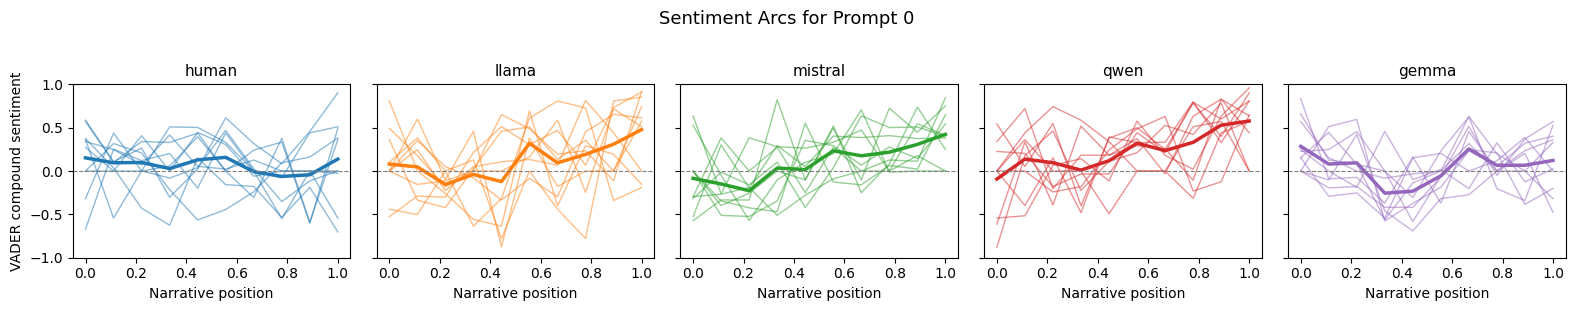

In [45]:
# Show sentiment arcs for one prompt across all sources
example_prompt = df_valid['prompt_id'].iloc[0]
subset = df_valid[df_valid['prompt_id'] == example_prompt]

fig, axes = plt.subplots(1, len(SOURCES), figsize=(16, 3), sharey=True)
colors = sns.color_palette('tab10', len(SOURCES))

for ax, source, color in zip(axes, SOURCES, colors):
    arcs = subset[subset['source'] == source]['sentiment_arc'].tolist()
    x = np.linspace(0, 1, ARC_LENGTH)
    for arc in arcs:
        ax.plot(x, arc, alpha=0.5, color=color, linewidth=1)
    if arcs:
        mean_arc = np.mean(arcs, axis=0)
        ax.plot(x, mean_arc, color=color, linewidth=2.5, label='mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(source, fontsize=11)
    ax.set_xlabel('Narrative position')
    ax.set_ylim(-1, 1)

axes[0].set_ylabel('VADER compound sentiment')
fig.suptitle(f'Sentiment Arcs for Prompt {example_prompt}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'sentiment_arcs_example.png', dpi=300, bbox_inches='tight')
plt.show()

## Compute D_narr per Prompt and Source

In [46]:
def mean_pairwise_l2(arcs):
    """
    Compute mean pairwise Euclidean distance between a list of arc vectors.
    Returns 0.0 if fewer than 2 arcs.
    """
    # Handle case with fewer than 2 arcs
    if len(arcs) < 2:
        return 0.0
    
    # Convert list of arcs to a numpy array for efficient computation
    arcs_arr = np.array(arcs)
    dists = [
        # Compute Euclidean distance between pairs of arcs
        np.linalg.norm(arcs_arr[i] - arcs_arr[j])
        for i, j in combinations(range(len(arcs_arr)), 2)
    ]
    return np.mean(dists)


# Compute D_narr for each (prompt_id, source) pair
results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results.append({
        'prompt_id': prompt_id,
        'source': source,
        'n_stories': len(arcs),
        'D_narr': d_narr
    })

df_narr = pd.DataFrame(results)
print(f"Computed D_narr for {len(df_narr)} (prompt, source) pairs.")
print(df_narr.groupby('source')['D_narr'].describe().round(4))

Computed D_narr for 500 (prompt, source) pairs.
         count    mean     std     min     25%     50%     75%     max
source                                                                
gemma    100.0  1.3457  0.2045  0.8633  1.1996  1.3044  1.5092  1.9008
human    100.0  1.4227  0.1743  1.0065  1.2984  1.4278  1.5395  1.8484
llama    100.0  1.3980  0.2316  0.9268  1.2501  1.3871  1.4845  2.3658
mistral  100.0  1.4746  0.2277  0.9238  1.3149  1.4710  1.6134  2.0499
qwen     100.0  1.3238  0.1936  0.9542  1.1895  1.3021  1.4186  1.8817


## Descriptive Analysis

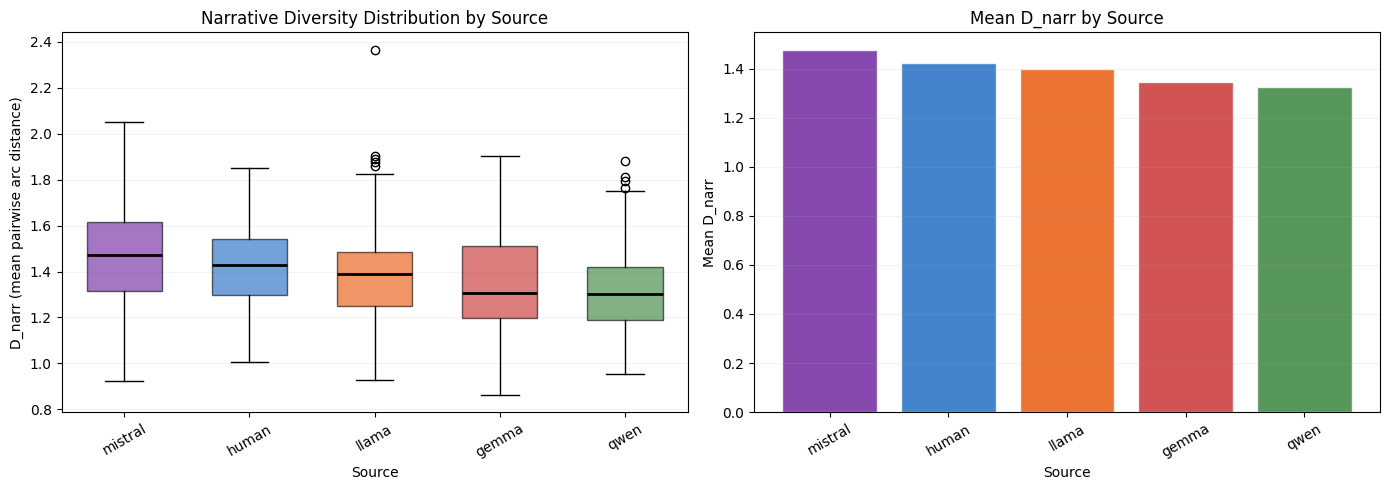

In [51]:
# D_narr by source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_order = df_narr.groupby('source')['D_narr'].median().sort_values(ascending=False).index.tolist()

# Boxplot (patch_artist mit Source-Farben)
data = [df_narr[df_narr['source'] == s]['D_narr'].values for s in source_order]
bp = axes[0].boxplot(data, labels=source_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, source in zip(bp['boxes'], source_order):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.6)
axes[0].set_title('Narrative Diversity Distribution by Source', fontsize=12)
axes[0].set_xlabel('Source')
axes[0].set_ylabel('D_narr (mean pairwise arc distance)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.15, axis='y')

# Mean D_narr
means = df_narr.groupby('source')['D_narr'].mean().reindex(source_order)
colors_bar = [SOURCE_COLORS[s] for s in source_order]
axes[1].bar(source_order, means.values, capsize=4,
            color=colors_bar, edgecolor='white', alpha=0.8)
axes[1].set_title('Mean D_narr by Source', fontsize=12)
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Mean D_narr')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig('narrative_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

## Mean Sentiment Arcs per Source (Aggregate)

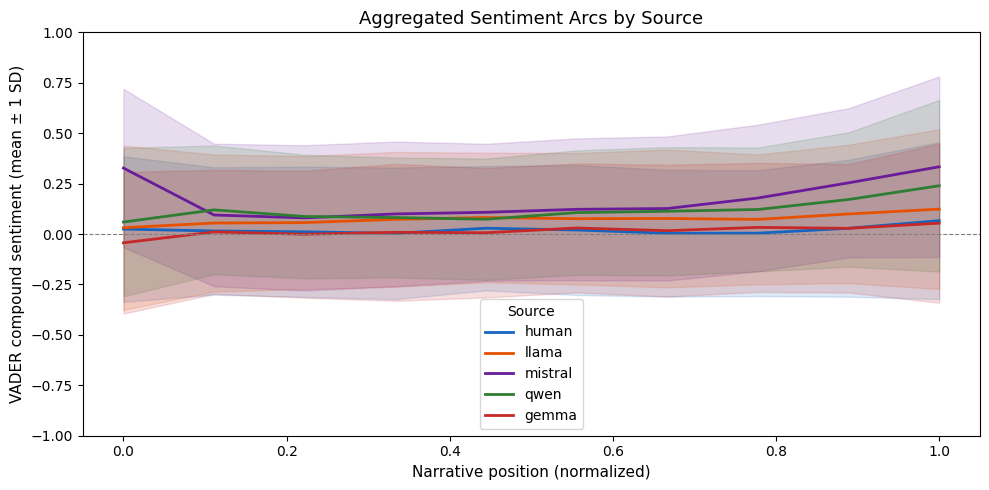

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 1, ARC_LENGTH)

for source in SOURCES:
    source_arcs = df_valid[df_valid['source'] == source]['sentiment_arc'].tolist()
    if not source_arcs:
        continue
    mean_arc = np.mean(source_arcs, axis=0)
    std_arc  = np.std(source_arcs, axis=0)
    color = SOURCE_COLORS[source]
    ax.plot(x, mean_arc, label=source, color=color, linewidth=2)
    ax.fill_between(x, mean_arc - std_arc, mean_arc + std_arc, alpha=0.15, color=color)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Narrative position (normalized)', fontsize=11)
ax.set_ylabel('VADER compound sentiment (mean ± 1 SD)', fontsize=11)
ax.set_title('Aggregated Sentiment Arcs by Source', fontsize=13)
ax.legend(title='Source')
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig('aggregated_sentiment_arcs.png', dpi=300, bbox_inches='tight')
plt.show()

## Arc-Shape-Classification

k-means with k=6 on all sentiment-arcs using the six basic forms of emotional arcs (Reagan et al., 2016): *Rags to Riches*, *Tragedy*, *Man in a Hole*, *Icarus*, *Cinderella*, *Oedipus*.

In [54]:
from sklearn.cluster import KMeans
from scipy.stats import entropy as scipy_entropy

np.random.seed(42)

# Arc-Matrix from all valid stories: each row is a story, each column is a point in the sentiment arc
arc_matrix = np.array(df_valid['sentiment_arc'].tolist())
df_valid = df_valid.reset_index(drop=True).copy()

# k-means with k=6
N_SHAPES = 6
kmeans = KMeans(n_clusters=N_SHAPES, random_state=42, n_init=20)
kmeans.fit(arc_matrix)
df_valid['arc_shape'] = kmeans.labels_

# Sort cluster by mean sentiment (positive to negative)
centroids = kmeans.cluster_centers_
shape_order = np.argsort(centroids.mean(axis=1))[::-1]
shape_remap = {int(old): int(new) for new, old in enumerate(shape_order)}
df_valid['arc_shape'] = df_valid['arc_shape'].map(shape_remap)
centroids = centroids[shape_order]

print(f'k-means with k={N_SHAPES} on {len(arc_matrix):,} sentiment-arcs')
print(f'\nCluster-Sizes:')
for i in range(N_SHAPES):
    n = (df_valid['arc_shape'] == i).sum()
    print(f'  Shape {i}: {n:4d} Stories ({n / len(df_valid) * 100:.1f}%)')

k-means with k=6 on 4,989 sentiment-arcs

Cluster-Sizes:
  Shape 0:  841 Stories (16.9%)
  Shape 1:  846 Stories (17.0%)
  Shape 2:  843 Stories (16.9%)
  Shape 3:  847 Stories (17.0%)
  Shape 4:  737 Stories (14.8%)
  Shape 5:  875 Stories (17.5%)


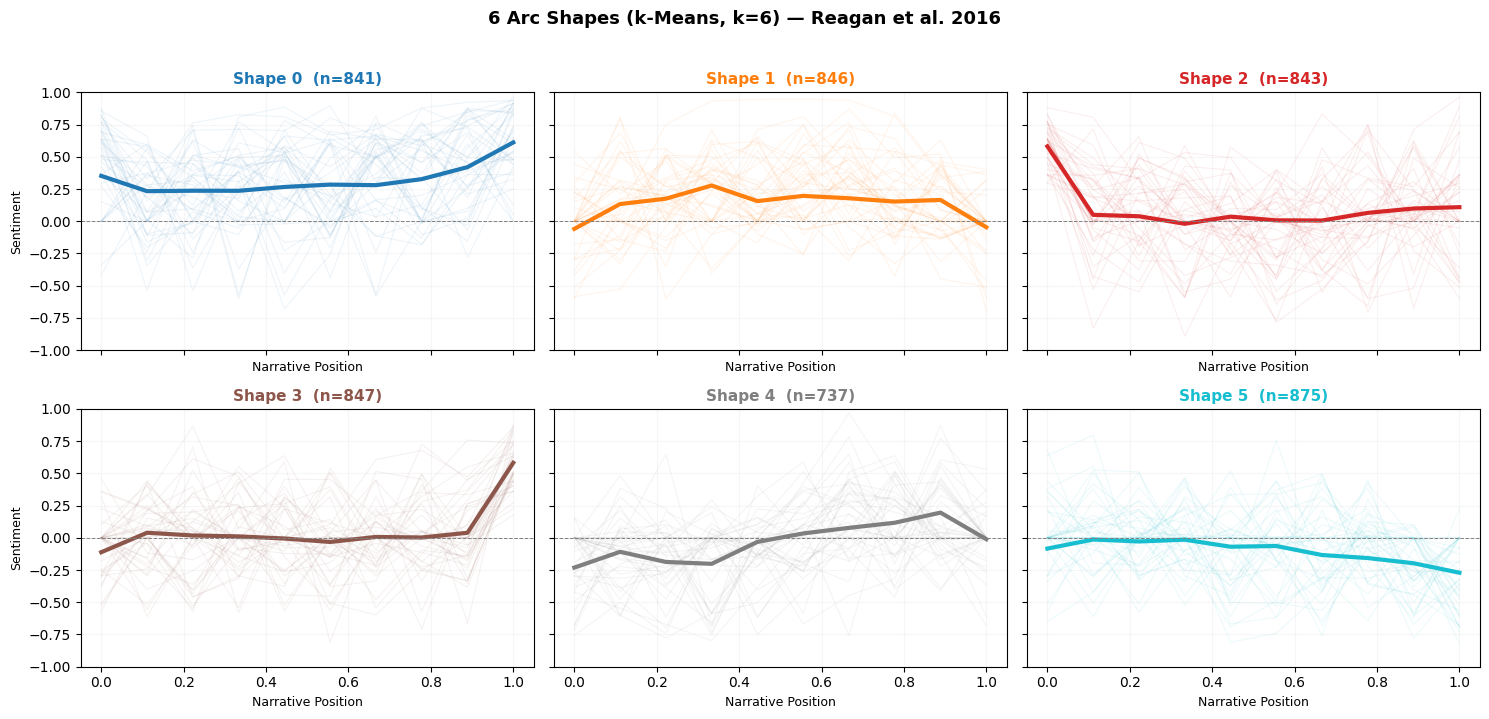

In [58]:
# Visualize 6 arc shapes: centroids + background arcs
SHAPE_COLORS = plt.cm.tab10(np.linspace(0, 0.9, N_SHAPES))
x = np.linspace(0, 1, ARC_LENGTH)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True, sharex=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    mask = df_valid['arc_shape'] == i
    cluster_arcs = arc_matrix[mask.values]
    n_show = min(40, len(cluster_arcs))
    sample_idx = np.random.choice(len(cluster_arcs), n_show, replace=False)
    for arc in cluster_arcs[sample_idx]:
        ax.plot(x, arc, alpha=0.08, color=SHAPE_COLORS[i], linewidth=0.8)
    ax.plot(x, centroids[i], color=SHAPE_COLORS[i], linewidth=3)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_ylim(-1, 1)
    ax.set_title(f'Shape {i}  (n={mask.sum()})', fontsize=11, fontweight='bold',
                 color=SHAPE_COLORS[i])
    ax.set_xlabel('Narrative Position', fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel('Sentiment', fontsize=9)
    ax.grid(True, alpha=0.1)

fig.suptitle('6 Arc Shapes (k-Means, k=6) — Reagan et al. 2016',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('arc_shapes_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

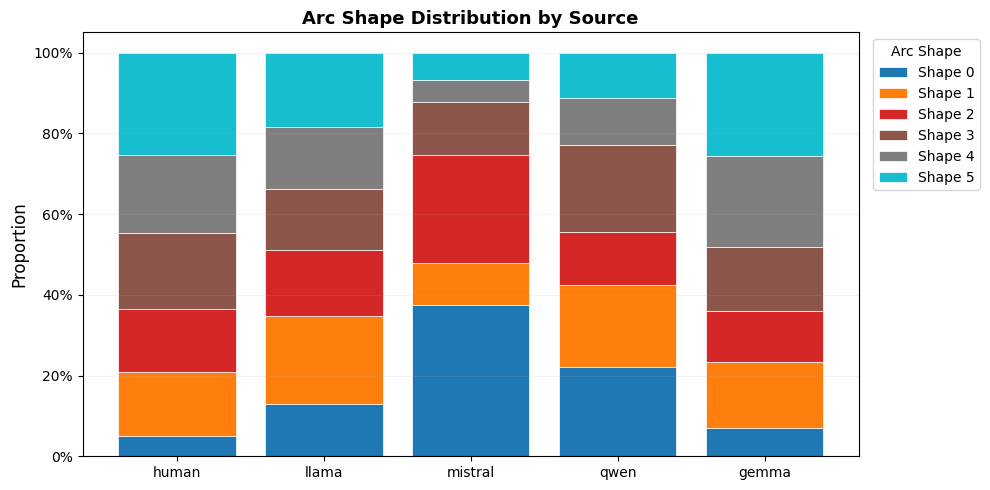

Entropy of arc shape distribution by source:
  (max. at uniform distribution: 2.585 bit)

  human     : H = 2.470 bit  ████████████████████████
  llama     : H = 2.565 bit  █████████████████████████
  mistral   : H = 2.258 bit  ██████████████████████
  qwen      : H = 2.525 bit  █████████████████████████
  gemma     : H = 2.481 bit  ████████████████████████


In [60]:
# Arc shape distribution by source (stacked bar chart)
from matplotlib.ticker import PercentFormatter

shape_dist = df_valid.groupby(['source', 'arc_shape']).size().unstack(fill_value=0)
shape_dist_norm = shape_dist.div(shape_dist.sum(axis=1), axis=0).reindex(SOURCES)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(SOURCES))
for i in range(N_SHAPES):
    vals = shape_dist_norm[i].values
    ax.bar(SOURCES, vals, bottom=bottom, label=f'Shape {i}',
           color=SHAPE_COLORS[i], edgecolor='white', linewidth=0.5)
    bottom += vals
ax.set_ylabel('Proportion', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Arc Shape Distribution by Source', fontsize=13, fontweight='bold')
ax.legend(title='Arc Shape', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('arc_shape_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Entropy of arc shape distribution by source
print('Entropy of arc shape distribution by source:')
print(f'  (max. at uniform distribution: {np.log2(N_SHAPES):.3f} bit)')
print()
for source in SOURCES:
    dist = shape_dist_norm.loc[source].values
    ent = scipy_entropy(dist, base=2)
    bar = '█' * int(ent * 10)
    print(f'  {source:10s}: H = {ent:.3f} bit  {bar}')

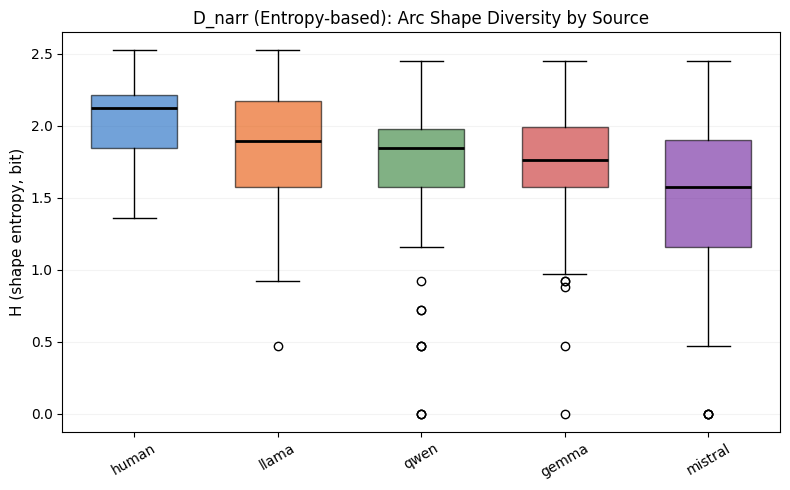

Correlation D_narr (distance) ↔ D_narr (entropy):
  Pearson r = 0.165

Mean shape entropy by source:
  human     : 2.043 ± 0.257 bit
  llama     : 1.853 ± 0.381 bit
  mistral   : 1.498 ± 0.567 bit
  qwen      : 1.709 ± 0.499 bit
  gemma     : 1.740 ± 0.406 bit


In [59]:
# Entropy-based D_narr per (prompt, source)
def shape_entropy(group):
    counts = group['arc_shape'].value_counts()
    return scipy_entropy((counts / counts.sum()).values, base=2)

entropy_results = (
    df_valid.groupby(['prompt_id', 'source'])
    .apply(shape_entropy)
    .reset_index(name='D_narr_entropy')
)

# Boxplot: entropy-based D_narr by source
fig, ax = plt.subplots(figsize=(8, 5))
ent_order = (entropy_results.groupby('source')['D_narr_entropy']
             .median().sort_values(ascending=False).index.tolist())
data_ent = [entropy_results[entropy_results['source'] == s]['D_narr_entropy'].values
            for s in ent_order]
bp = ax.boxplot(data_ent, labels=ent_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, source in zip(bp['boxes'], ent_order):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.6)
ax.set_title('D_narr (Entropy-based): Arc Shape Diversity by Source', fontsize=12)
ax.set_ylabel('H (shape entropy, bit)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.show()

# Correlation with distance-based D_narr
merged = df_narr[['prompt_id', 'source', 'D_narr']].merge(
    entropy_results, on=['prompt_id', 'source']
)
r = np.corrcoef(merged['D_narr'], merged['D_narr_entropy'])[0, 1]
print(f'Correlation D_narr (distance) ↔ D_narr (entropy):')
print(f'  Pearson r = {r:.3f}')
print()
print('Mean shape entropy by source:')
for source in SOURCES:
    vals = entropy_results[entropy_results['source'] == source]['D_narr_entropy']
    print(f'  {source:10s}: {vals.mean():.3f} ± {vals.std():.3f} bit')

## Statistical Testing: Does Source Affect D_narr?

In [63]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations as combos

groups = [df_narr[df_narr['source'] == s]['D_narr'].values for s in SOURCES]

# Kruskal-Wallis (non-parametric ANOVA alternative)
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis test across sources:")
print(f"  H = {stat:.4f}, p = {p:.4f}")
if p < 0.05:
    print("  -> Significant difference in D_narr across sources (p < 0.05)")
else:
    print("  -> No significant difference detected (p ≥ 0.05)")

print("\nPairwise Mann-Whitney U tests (Bonferroni corrected):")
pairs = list(combos(SOURCES, 2))
alpha_corrected = 0.05 / len(pairs)
print(f"  Bonferroni threshold: p < {alpha_corrected:.4f}")

for s1, s2 in pairs:
    g1 = df_narr[df_narr['source'] == s1]['D_narr'].values
    g2 = df_narr[df_narr['source'] == s2]['D_narr'].values
    u, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p_mw < alpha_corrected else ('*' if p_mw < 0.05 else 'ns')
    print(f"  {s1:10s} vs {s2:10s}: U={u:.0f}, p={p_mw:.4f}  {sig}")

Kruskal-Wallis test across sources:
  H = 34.1331, p = 0.0000
  -> Significant difference in D_narr across sources (p < 0.05)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  Bonferroni threshold: p < 0.0050
  human      vs llama     : U=5654, p=0.1103  ns
  human      vs mistral   : U=4396, p=0.1403  ns
  human      vs qwen      : U=6656, p=0.0001  ***
  human      vs gemma     : U=6213, p=0.0031  ***
  llama      vs mistral   : U=3855, p=0.0052  *
  llama      vs qwen      : U=5914, p=0.0256  *
  llama      vs gemma     : U=5592, p=0.1484  ns
  mistral    vs qwen      : U=7012, p=0.0000  ***
  mistral    vs gemma     : U=6626, p=0.0001  ***
  qwen       vs gemma     : U=4703, p=0.4688  ns


## Effect Size: Human vs. LLM

In [66]:
def cohens_d(a, b):
    "ARC_LENGTH Cohen's d effect size between two arrays"
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

print('Effect Size Human vs. Model for D_narr')
print(f'{"Model":<10} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 46)
h = df_narr[df_narr['source'] == 'human']['D_narr'].values
for source in SOURCES[1:]:
    m = df_narr[df_narr['source'] == source]['D_narr'].values
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')

Effect Size Human vs. Model for D_narr
Model         Cohen d   Strength     U-test p
----------------------------------------------
llama          +0.121      small     1.10e-01
mistral        -0.257      small     1.40e-01
qwen           +0.540     medium     5.23e-05
gemma          +0.407      small     3.05e-03


## Diversity Gap (Human, Model)

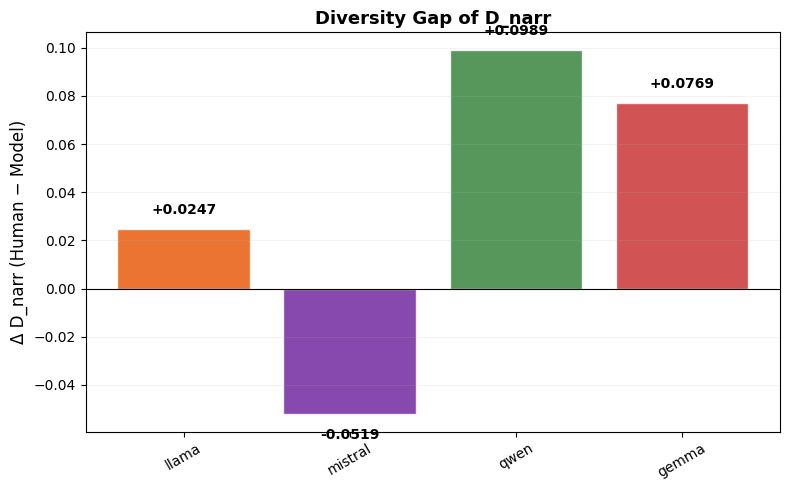


Diversity Gap (Human − Model):
  llama     : +0.0247
  mistral   : -0.0519
  qwen      : +0.0989
  gemma     : +0.0769


In [68]:
human_mean = df_narr[df_narr['source'] == 'human']['D_narr'].mean()
llm_sources = SOURCES[1:]

deltas = [
    human_mean - df_narr[df_narr['source'] == s]['D_narr'].mean()
    for s in llm_sources
]
colors_gap = [SOURCE_COLORS[s] for s in llm_sources]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(llm_sources, deltas, color=colors_gap, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Δ D_narr (Human − Model)', fontsize=12)
ax.set_title('Diversity Gap of D_narr', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')

for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2, delta + (0.005 if delta >= 0 else -0.012),
            f'{delta:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDiversity Gap (Human − Model):')
for s, d in zip(llm_sources, deltas):
    print(f'  {s:10s}: {d:+.4f}')